# Term Life Cash-Flow & Premium Derivation

**Core question:** How does a life insurer convert mortality, lapse, expense, and investment
assumptions into an indicated premium?

This notebook derives the pricing engine's mathematics from first principles, in the order an
actuarial student would learn it, and checks every derivation against `life_pricing` — the
production package this project ships (`src/life_pricing/`). Every real assumption (mortality
table, lapse table, expenses, target margin) is loaded from `config/assumptions.yaml` through
that package, never retyped by hand.

**Contents**

1. [One representative policy](#Part-1) — load real assumptions, print the mortality and lapse
   vectors, build a "Policy X-Ray."
2. [Competing decrements, derived by hand](#Part-2) — years 1–3 worked manually, reconciled
   against the engine.
3. [Cash-flow timing](#Part-3) — beginning-of-year premiums vs. end-of-year claims, and what a
   one-year timing simplification costs.
4. [The premium equation](#Part-4) — the full algebra, derived in Markdown, solved by hand and
   checked against the engine's closed-form solver.
5. [Decomposing the premium](#Part-5) — where every dollar of premium actually goes.
6. [What drives the premium?](#Part-6) — one-at-a-time assumption shocks and premium elasticity.

> **A note on this notebook's interest rate.** The project's real base interest assumption is
> **5.16%** — the 20-Year Treasury Constant Maturity yield, a deliberately precise, citable
> anchor (see `ACTUARIAL_ASSUMPTIONS.md`). This notebook instead fixes **i = 4%**, a clean round
> number, purely so the hand-worked arithmetic below is easy to follow and re-check by hand — a
> common textbook device, not a change to the production pricing engine. The override is applied
> explicitly, below, via `life_pricing.scenario.apply_scenario` — the same sanctioned mechanism
> the codebase already uses for sensitivity testing — and is never written back to
> `config/assumptions.yaml`. The target PV margin of **10%**, by contrast, needs no override: it
> already matches the project's real base assumption exactly.

## Setup

Import the production package. `ROOT` is resolved relative to the notebook's own working
directory so this runs identically whether launched from the repo root or from `notebooks/`.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from life_pricing.config import load_assumptions
from life_pricing.mortality import mortality_curve_for_policy, write_processed_tables
from life_pricing.projection import project_policy
from life_pricing.premium import solve_annual_premium
from life_pricing.cashflow import build_policy_cash_flows, summarize_policy, year_expenses
from life_pricing.scenario import apply_scenario, price_policy_under_assumptions

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Validated categorical palette (fixed order — see dataviz notes in AGENTS.md workflow).
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, SECONDARY_INK, MUTED, GRID, BASELINE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": SECONDARY_INK,
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "grid.color": GRID,
    "font.size": 10,
})

# Idempotent: regenerates data/processed/ mortality CSVs from data/raw/ (Loop 3),
# matching scripts/generate_executive_report.py's Step 0 -- so this notebook runs
# standalone from a fresh clone as long as data/raw/ is populated.
write_processed_tables()

print("Setup complete.")

Setup complete.


<a id="Part-1"></a>
## Part 1 — Define one representative policy

We fix one policy for the entire notebook so every later section builds on the same numbers.

In [2]:
BASE_ASSUMPTIONS = load_assumptions(ROOT / "config" / "assumptions.yaml")

POLICY = dict(
    issue_age=40,
    sex="male",
    smoker_status="nonsmoker",
    underwriting_class="Standard",
    face_amount=500_000,
)

print("Policy characteristics:")
for key, value in POLICY.items():
    print(f"  {key:<20s} = {value}")

print()
print("Product/assumption facts pulled from the package (config/assumptions.yaml), not retyped:")
print(f"  Term                         = {BASE_ASSUMPTIONS.term_years} years")
print(f"  Issue age range              = [{BASE_ASSUMPTIONS.issue_age_min}, {BASE_ASSUMPTIONS.issue_age_max}]")
print(f"  Mortality reference basis    = {BASE_ASSUMPTIONS.mortality_reference_basis}")
print(f"  Real base interest rate      = {BASE_ASSUMPTIONS.discount_rate:.4%}  (see ACTUARIAL_ASSUMPTIONS.md)")
print(f"  Real base target PV margin   = {BASE_ASSUMPTIONS.target_profit_margin:.2%}")

Policy characteristics:
  issue_age            = 40
  sex                  = male
  smoker_status        = nonsmoker
  underwriting_class   = Standard
  face_amount          = 500000

Product/assumption facts pulled from the package (config/assumptions.yaml), not retyped:
  Term                         = 20 years
  Issue age range              = [25, 60]
  Mortality reference basis    = 2015 VBT Smoker Distinct tables (SOA mort.soa.org), select & ultimate, by sex and smoker status
  Real base interest rate      = 5.1600%  (see ACTUARIAL_ASSUMPTIONS.md)
  Real base target PV margin   = 10.00%


Now fix this notebook's interest rate at **i = 4%** for pedagogical clarity (see the note at the
top of the notebook), via the codebase's own scenario-override mechanism. The target margin needs
no override — the real base assumption is already 10%.

In [3]:
ASSUMPTIONS = apply_scenario(
    BASE_ASSUMPTIONS, lambda raw: raw["interest"].update(annual_effective_rate=0.04)
)

assert ASSUMPTIONS.discount_rate == 0.04
assert ASSUMPTIONS.target_profit_margin == BASE_ASSUMPTIONS.target_profit_margin == 0.10
# apply_scenario deep-copies the raw dict -- confirm the base assumptions object (and the
# underlying YAML) were never touched.
assert BASE_ASSUMPTIONS.discount_rate != 0.04

i = ASSUMPTIONS.discount_rate
m = ASSUMPTIONS.target_profit_margin
print(f"Notebook interest rate   i = {i:.2%}")
print(f"Notebook target PV margin m = {m:.2%}")

Notebook interest rate   i = 4.00%
Notebook target PV margin m = 10.00%


### Mortality and lapse vectors

$$ q_1, q_2, \ldots, q_{20} \qquad\text{and}\qquad l_1, l_2, \ldots, l_{20} $$

`mortality_curve_for_policy` combines the base sex/smoker 2015 VBT select table with this
policy's underwriting-class relativity (Loop 12b, face-amount-band-specific) and the configured
mortality stress multiplier. The lapse vector comes straight from `assumptions.lapse_rates`, the
real SOA 2009-13 Persistency Update curve.

In [4]:
qx = mortality_curve_for_policy(ASSUMPTIONS, **POLICY)
lapse = [ASSUMPTIONS.lapse_rates[t] for t in range(1, ASSUMPTIONS.term_years + 1)]

print("Mortality vector q_t:")
for t, q in enumerate(qx, start=1):
    print(f"  q_{t:<2d} = {q:.6f}")

print()
print("Lapse vector l_t:")
for t, l in enumerate(lapse, start=1):
    print(f"  l_{t:<2d} = {l:.6f}")

Mortality vector q_t:
  q_1  = 0.000170
  q_2  = 0.000300
  q_3  = 0.000430
  q_4  = 0.000510
  q_5  = 0.000590
  q_6  = 0.000680
  q_7  = 0.000760
  q_8  = 0.000850
  q_9  = 0.000970
  q_10 = 0.001120
  q_11 = 0.001250
  q_12 = 0.001380
  q_13 = 0.001550
  q_14 = 0.001730
  q_15 = 0.001910
  q_16 = 0.002130
  q_17 = 0.002430
  q_18 = 0.002800
  q_19 = 0.003240
  q_20 = 0.003690

Lapse vector l_t:
  l_1  = 0.060000
  l_2  = 0.055000
  l_3  = 0.047000
  l_4  = 0.043000
  l_5  = 0.040000
  l_6  = 0.037000
  l_7  = 0.034000
  l_8  = 0.032000
  l_9  = 0.031000
  l_10 = 0.030000
  l_11 = 0.030000
  l_12 = 0.027000
  l_13 = 0.027000
  l_14 = 0.025000
  l_15 = 0.027000
  l_16 = 0.029000
  l_17 = 0.029000
  l_18 = 0.034000
  l_19 = 0.042000
  l_20 = 0.310000


### "Policy X-Ray"

One table with every competing-decrement quantity for all 20 years, produced by
`life_pricing.projection.project_policy` — the same engine every other loop in this project
calls.

In [5]:
projection = project_policy(
    ASSUMPTIONS, issue_age=POLICY["issue_age"], mortality_rates_qx=qx, face_amount=POLICY["face_amount"]
)

xray = pd.DataFrame({
    "Year": [r.policy_year for r in projection],
    "Age": [r.attained_age for r in projection],
    "q_t": [r.mortality_rate_qx for r in projection],
    "Lapse": [r.lapse_rate for r in projection],
    "BOY In-force": [r.beginning_inforce_probability for r in projection],
    "Death Prob": [r.death_probability for r in projection],
    "Lapse Prob": [r.lapse_probability for r in projection],
    "EOY In-force": [r.ending_inforce_probability for r in projection],
})
xray_display = xray.set_index("Year")
for col in ["q_t", "Lapse", "BOY In-force", "Death Prob", "Lapse Prob", "EOY In-force"]:
    xray_display[col] = xray_display[col].map(lambda x: f"{x:.6f}")
xray_display

,Age,q_t,Lapse,BOY In-force,Death Prob,Lapse Prob,EOY In-force
Year,,,,,,,
1,40,0.000170,0.060000,1.000000,0.000170,0.059990,0.939840
2,41,0.000300,0.055000,0.939840,0.000282,0.051676,0.887883
3,42,0.000430,0.047000,0.887883,0.000382,0.041713,0.845788
4,43,0.000510,0.043000,0.845788,0.000431,0.036350,0.809007
5,44,0.000590,0.040000,0.809007,0.000477,0.032341,0.776188
6,45,0.000680,0.037000,0.776188,0.000528,0.028699,0.746961
7,46,0.000760,0.034000,0.746961,0.000568,0.025377,0.721016
8,47,0.000850,0.032000,0.721016,0.000613,0.023053,0.697350
9,48,0.000970,0.031000,0.697350,0.000676,0.021597,0.675077


Visually, each policy year is one transition:

$$ I_t \rightarrow \begin{cases} D_t & \text{(dies)} \\ L_t & \text{(lapses)} \\ I_{t+1} & \text{(survives in-force)} \end{cases} $$

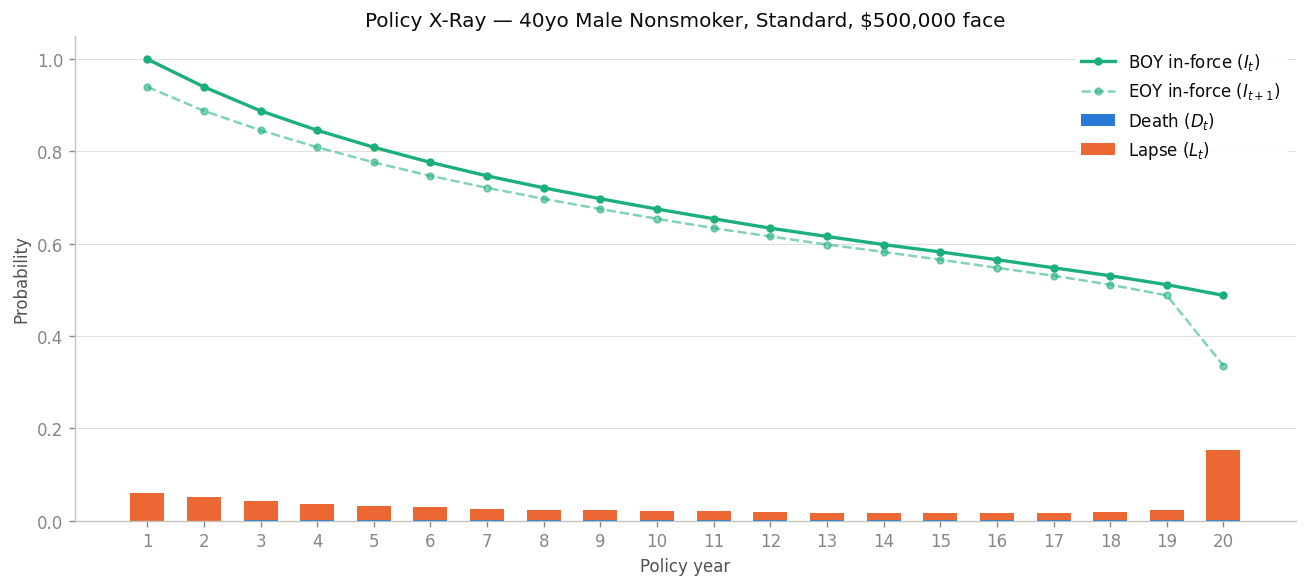

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
years = xray["Year"]

ax.bar(years, xray["Death Prob"], color=BLUE, width=0.6, label="Death ($D_t$)", zorder=2)
ax.bar(
    years, xray["Lapse Prob"], bottom=xray["Death Prob"], color=ORANGE, width=0.6,
    label="Lapse ($L_t$)", zorder=2,
)
ax.plot(years, xray["BOY In-force"], color=AQUA, marker="o", markersize=4, linewidth=2, label="BOY in-force ($I_t$)", zorder=3)
ax.plot(
    years, xray["EOY In-force"], color=AQUA, linestyle="--", marker="o", markersize=4, linewidth=1.5,
    alpha=0.55, label="EOY in-force ($I_{t+1}$)", zorder=3,
)

ax.set_xlabel("Policy year")
ax.set_ylabel("Probability")
ax.set_title(
    f"Policy X-Ray — {POLICY['issue_age']}yo {POLICY['sex'].title()} "
    f"{POLICY['smoker_status'].title()}, {POLICY['underwriting_class']}, ${POLICY['face_amount']:,} face"
)
ax.set_xticks(range(1, ASSUMPTIONS.term_years + 1))
ax.grid(axis="y", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper right", frameon=True, framealpha=0.9, edgecolor="none")
plt.tight_layout()
plt.show()

Note the Death bars ($D_t$) are barely visible on this scale — that's realistic, not a plotting bug: at these attained ages (40-59), $q_t$ is roughly two orders of magnitude smaller than $l_t$ (compare the printed vectors above), so lapse dominates the near-term decrement experience for this policy almost entirely.

<a id="Part-2"></a>
## Part 2 — Derive competing decrements manually

Before trusting `project_policy()`, we derive the first three years of $I_t$, $D_t$, $L_t$ by
hand, then check the arithmetic against the engine output already computed above.

**Year 1**

$$ I_1 = 1 $$
$$ D_1 = I_1 \, q_1 $$
$$ L_1 = I_1 (1 - q_1)\, l_1 $$
$$ I_2 = I_1 - D_1 - L_1 $$

In [7]:
q1, q2, q3 = qx[0], qx[1], qx[2]
l1, l2, l3 = lapse[0], lapse[1], lapse[2]

I1 = 1.0
D1 = I1 * q1
L1 = I1 * (1 - q1) * l1
I2 = I1 - D1 - L1

print("Year 1")
print(f"  I_1 = {I1:.10f}")
print(f"  D_1 = I_1 * q_1              = {I1:.6f} * {q1:.6f}                 = {D1:.10f}")
print(f"  L_1 = I_1 * (1 - q_1) * l_1  = {I1:.6f} * {1 - q1:.6f} * {l1:.6f}  = {L1:.10f}")
print(f"  I_2 = I_1 - D_1 - L_1        = {I1:.6f} - {D1:.6f} - {L1:.6f}      = {I2:.10f}")

Year 1
  I_1 = 1.0000000000
  D_1 = I_1 * q_1              = 1.000000 * 0.000170                 = 0.0001700000
  L_1 = I_1 * (1 - q_1) * l_1  = 1.000000 * 0.999830 * 0.060000  = 0.0599898000
  I_2 = I_1 - D_1 - L_1        = 1.000000 - 0.000170 - 0.059990      = 0.9398402000


**Year 2** — same recursion, starting from the $I_2$ just derived.

$$ D_2 = I_2\, q_2 \qquad L_2 = I_2 (1 - q_2)\, l_2 \qquad I_3 = I_2 - D_2 - L_2 $$

In [8]:
D2 = I2 * q2
L2 = I2 * (1 - q2) * l2
I3 = I2 - D2 - L2

print("Year 2")
print(f"  I_2 = {I2:.10f}")
print(f"  D_2 = I_2 * q_2              = {I2:.6f} * {q2:.6f}                 = {D2:.10f}")
print(f"  L_2 = I_2 * (1 - q_2) * l_2  = {I2:.6f} * {1 - q2:.6f} * {l2:.6f}  = {L2:.10f}")
print(f"  I_3 = I_2 - D_2 - L_2        = {I2:.6f} - {D2:.6f} - {L2:.6f}      = {I3:.10f}")

Year 2
  I_2 = 0.9398402000
  D_2 = I_2 * q_2              = 0.939840 * 0.000300                 = 0.0002819521
  L_2 = I_2 * (1 - q_2) * l_2  = 0.939840 * 0.999700 * 0.055000  = 0.0516757036
  I_3 = I_2 - D_2 - L_2        = 0.939840 - 0.000282 - 0.051676      = 0.8878825443


**Year 3**

$$ D_3 = I_3\, q_3 \qquad L_3 = I_3 (1 - q_3)\, l_3 \qquad I_4 = I_3 - D_3 - L_3 $$

In [9]:
D3 = I3 * q3
L3 = I3 * (1 - q3) * l3
I4 = I3 - D3 - L3

print("Year 3")
print(f"  I_3 = {I3:.10f}")
print(f"  D_3 = I_3 * q_3              = {I3:.6f} * {q3:.6f}                 = {D3:.10f}")
print(f"  L_3 = I_3 * (1 - q_3) * l_3  = {I3:.6f} * {1 - q3:.6f} * {l3:.6f}  = {L3:.10f}")
print(f"  I_4 = I_3 - D_3 - L_3        = {I3:.6f} - {D3:.6f} - {L3:.6f}      = {I4:.10f}")

Year 3
  I_3 = 0.8878825443
  D_3 = I_3 * q_3              = 0.887883 * 0.000430                 = 0.0003817895
  L_3 = I_3 * (1 - q_3) * l_3  = 0.887883 * 0.999570 * 0.047000  = 0.0417125355
  I_4 = I_3 - D_3 - L_3        = 0.887883 - 0.000382 - 0.041713      = 0.8457882193


### Manual vs. engine

In [10]:
compare = pd.DataFrame({
    "Quantity": ["I_2", "D_1", "L_1", "I_3", "D_2", "L_2", "I_4", "D_3", "L_3"],
    "Manual": [I2, D1, L1, I3, D2, L2, I4, D3, L3],
    "Engine": [
        projection[0].ending_inforce_probability, projection[0].death_probability, projection[0].lapse_probability,
        projection[1].ending_inforce_probability, projection[1].death_probability, projection[1].lapse_probability,
        projection[2].ending_inforce_probability, projection[2].death_probability, projection[2].lapse_probability,
    ],
})
compare["Abs Diff"] = (compare["Manual"] - compare["Engine"]).abs()
compare

,Quantity,Manual,Engine,Abs Diff
0,I_2,0.939840,0.939840,0.000000
1,D_1,0.000170,0.000170,0.000000
2,L_1,0.059990,0.059990,0.000000
3,I_3,0.887883,0.887883,0.000000
4,D_2,0.000282,0.000282,0.000000
5,L_2,0.051676,0.051676,0.000000
6,I_4,0.845788,0.845788,0.000000
7,D_3,0.000382,0.000382,0.000000
8,L_3,0.041713,0.041713,0.000000


### Actuarial unit test inside the notebook

Reconciliation identity, checked across **all 20 years** of the engine's own projection (not just
the three we did by hand):

$$ Error_t = I_t - D_t - L_t - I_{t+1} $$

In [11]:
errors = []
for idx, row in enumerate(projection):
    I_t = row.beginning_inforce_probability
    D_t = row.death_probability
    L_t = row.lapse_probability
    I_next = projection[idx + 1].beginning_inforce_probability if idx + 1 < len(projection) else row.ending_inforce_probability
    errors.append(I_t - D_t - L_t - I_next)

max_error = max(abs(e) for e in errors)
status = "PASS" if max_error < 1e-9 else "FAIL"

print(f"Maximum decrement reconciliation error: {max_error:.1e}")
print(status)

assert status == "PASS", "Competing-decrement identity failed to reconcile across the 20-year projection."

Maximum decrement reconciliation error: 1.1e-16
PASS


<a id="Part-3"></a>
## Part 3 — Separate cash-flow timing

```
t=0        t=1        t=2        ...        t=20
 |----------|----------|-----------------------|
 Premium 1  Claim 1
            Premium 2  Claim 2
```

Premium 1 is collected **at issue** ($t=0$), not at the end of year 1. Claim 1 (if the policyholder
dies in year 1) is paid at the **end** of year 1 ($t=1$). Each subsequent premium/claim pair shifts
one year later. Two different points in time within the same policy year call for two different
discount factors:

**Beginning-of-year premium**
$$ v^{t-1} = (1+i)^{-(t-1)} $$

**End-of-year claim**
$$ v^{t} = (1+i)^{-t} $$

A model that discounts *both* by the same $v^t$ is implicitly treating the beginning-of-year
premium as though it arrived a year late.

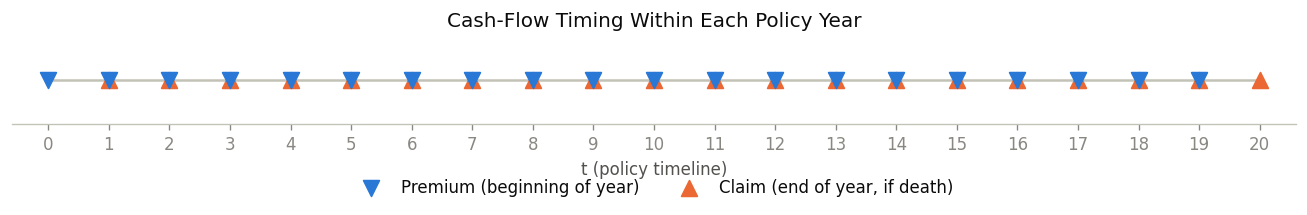

In [12]:
fig, ax = plt.subplots(figsize=(11, 2.4))

for t in range(1, ASSUMPTIONS.term_years + 1):
    ax.scatter(t - 1, 0, marker="v", s=90, color=BLUE, zorder=3, label="Premium (beginning of year)" if t == 1 else None)
    ax.scatter(t, 0, marker="^", s=90, color=ORANGE, zorder=3, label="Claim (end of year, if death)" if t == 1 else None)

ax.hlines(0, 0, ASSUMPTIONS.term_years, color=BASELINE, linewidth=1.5, zorder=1)
ax.set_xlim(-0.6, ASSUMPTIONS.term_years + 0.6)
ax.set_yticks([])
ax.set_xticks(range(0, ASSUMPTIONS.term_years + 1))
ax.set_xlabel("t (policy timeline)")
ax.set_title("Cash-Flow Timing Within Each Policy Year")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

### Two pricing bases

**Simplified timing** (a single end-of-year factor for every cash flow — what this project's own
code did before its V1.1 correction; see `ACTUARIAL_ASSUMPTIONS.md`, "Cash-flow timing (V1.1)"):

$$ PV(Prem_t) = I_t \, P \, v^{t} $$

**Refined timing** (what `life_pricing.premium` solves today):

$$ PV(Prem_t) = I_t \, P \, v^{t-1} $$

The function below is **not** part of the package — it is a notebook-only replica of the
pre-V1.1 model, reconstructed purely so we can quantify what the timing correction changed.

In [13]:
def solve_premium_simplified_timing(assumptions, projection, target_margin=None):
    """Notebook-only replica of the PRE-V1.1 model: every cash-flow component
    (premium, claim, acquisition/maintenance expense) discounted at the single
    end-of-year factor v_t = (1+i)^-t.
    """

    margin = assumptions.target_profit_margin if target_margin is None else target_margin
    A = B = C = 0.0
    for row in projection:
        v = row.discount_factor  # one factor for every component
        I_t = row.beginning_inforce_probability
        claim = row.expected_death_benefit
        acquisition_expense, maintenance_expense, coef_t = year_expenses(
            assumptions, row.policy_year, I_t, expected_premium=I_t
        )
        A += v * (I_t - coef_t)
        B += v * claim + v * acquisition_expense + v * maintenance_expense
        C += v * I_t
    return B / (A - margin * C)


P_simplified = solve_premium_simplified_timing(ASSUMPTIONS, projection)
P_refined = solve_annual_premium(ASSUMPTIONS, projection)

delta_P = P_simplified - P_refined
pct_delta_P = delta_P / P_refined

print(f"Simplified-timing indicated premium (P_simplified): ${P_simplified:,.4f}")
print(f"Refined-timing indicated premium    (P_refined):    ${P_refined:,.4f}")
print()
print(f"ΔP  = P_simplified - P_refined = ${delta_P:,.4f}")
print(f"%ΔP = ΔP / P_refined           = {pct_delta_P:.4%}")

Simplified-timing indicated premium (P_simplified): $723.1932
Refined-timing indicated premium    (P_refined):    $697.4333

ΔP  = P_simplified - P_refined = $25.7598
%ΔP = ΔP / P_refined           = 3.6935%


**How much premium error does a one-year timing simplification create?**

The number printed above is the answer for this specific policy and this 4% interest assumption
— and it is exactly the kind of question an actuarial interviewer could ask. Two effects are
mixed together in $\Delta P$: (1) the simplified model discounts the premium annuity $C$ one extra
period, which *understates* the PV of premium collected per dollar of $P$, pushing the solved
premium *up*; (2) the simplified model also discounts acquisition expense (incurred at issue) one
extra period, *understating* that cost, which pushes the solved premium back *down*. The sign and
size of $\Delta P$ above is the net of those two effects for this policy — not something you can
guess from the formulas alone, which is exactly why we compute it rather than assert it.

<a id="Part-4"></a>
## Part 4 — Build the premium mathematically

### Premium

$$ PVPremium(P) = P \cdot C, \qquad C = \sum_t I_t \, v^{t-1} $$

### Claims

$$ PVClaims = \sum_t I_t \, q_t \, F \, v^{t} $$

### Expenses

Expenses split into a part that does **not** depend on the premium level (acquisition fixed cost
at issue, plus ongoing maintenance) and a part that **scales linearly with $P$** (acquisition and
renewal percent-of-premium load):

$$ PVExpenses = PVFixedExpense + P \cdot PVVariableExpense $$

where $PVFixedExpense$ bundles the acquisition fixed cost (discounted at $v^{t-1}$, same timing as
premium — it is incurred at issue) and maintenance expense (discounted at its own mid-year
$v^{t-0.5}$, per Part 3's timing discussion — `life_pricing.projection`'s
`discount_factor_maintenance`), and $PVVariableExpense = \sum_t coef_t \, v^{t-1}$ is the
percent-of-premium expense coefficient's PV at a *unit* premium ($coef_t$ = the acquisition-% rate
in year 1, the renewal-% rate afterward, each times $I_t$).

### Profit and the premium equation

$$ PVProfit = PVPremium - PVClaims - PVExpenses = P\big(C - PVVariableExpense\big) - \big(PVClaims + PVFixedExpense\big) $$

Setting $PVProfit / PVPremium = m$ and solving for $P$:

$$ \frac{P\big(C - PVVariableExpense\big) - \big(PVClaims + PVFixedExpense\big)}{P \cdot C} = m $$

$$ P\big(C - PVVariableExpense - mC\big) = PVClaims + PVFixedExpense $$

$$ \boxed{P = \dfrac{PVClaims + PVFixedExpense}{C(1-m) - PVVariableExpense}} $$

This is the closed form `life_pricing.premium.solve_annual_premium` actually implements — with
$C - PVVariableExpense \equiv A$, $PVClaims + PVFixedExpense \equiv B$ in that module's own
notation, so $P = B / (A - mC)$. We now compute $C$, $PVClaims$, $PVFixedExpense$, and
$PVVariableExpense$ by hand, **without calling `solve_annual_premium`**, and only then compare to
the engine.

In [14]:
C = 0.0
PV_claims = 0.0
PV_fixed_expense = 0.0
PV_variable_expense = 0.0

for row in projection:
    v_prem = row.discount_factor_premium   # v^(t-1)
    v_claim = row.discount_factor          # v^t
    v_maint = row.discount_factor_maintenance
    I_t = row.beginning_inforce_probability

    C += I_t * v_prem
    PV_claims += row.expected_death_benefit * v_claim

    acquisition_expense, maintenance_expense, coef_t = year_expenses(
        ASSUMPTIONS, row.policy_year, I_t, expected_premium=I_t
    )
    PV_fixed_expense += acquisition_expense * v_prem + maintenance_expense * v_maint
    PV_variable_expense += coef_t * v_prem

manual_premium = (PV_claims + PV_fixed_expense) / (C * (1 - m) - PV_variable_expense)
engine_premium = solve_annual_premium(ASSUMPTIONS, projection)
difference = manual_premium - engine_premium

print(f"C   (PV premium annuity factor, per $1 of P) = {C:.8f}")
print(f"PV Claims                                     = {PV_claims:,.6f}")
print(f"PV Fixed Expense (acquisition + maintenance)  = {PV_fixed_expense:,.6f}")
print(f"PV Variable Expense (per $1 of P)              = {PV_variable_expense:.8f}")
print()
print(f"manual_premium = ${manual_premium:,.6f}")
print(f"engine_premium = ${engine_premium:,.6f}")
print(f"difference     = {difference:.2e}")

assert abs(difference) < 1e-6, "Hand-derived closed form disagrees with the production solver."
# Cross-check against Part 3's refined-timing premium -- same assumptions, same formula.
assert abs(engine_premium - P_refined) < 1e-9
print()
print("PASS — manual derivation matches the production solver (and Part 3's P_refined).")

C   (PV premium annuity factor, per $1 of P) = 10.22449373
PV Claims                                     = 5,170.224298
PV Fixed Expense (acquisition + maintenance)  = 751.556458
PV Variable Expense (per $1 of P)              = 0.71122469

manual_premium = $697.433344
engine_premium = $697.433344
difference     = -3.41e-13

PASS — manual derivation matches the production solver (and Part 3's P_refined).


<a id="Part-5"></a>
## Part 5 — Decompose the premium

A naive split of the premium *level* itself, $P = P_{mortality} + P_{expenses} + P_{profit} +
\text{interaction/timing}$, does not actually work cleanly: the expense terms scale with $P$
(that coupling is exactly the $PVVariableExpense$ term in Part 4), so mortality, expenses, and
profit are not additively separable pieces of $P$ in general. The rigorous and standard actuarial
way to answer "where does the premium go" is instead to decompose the **present value of premium
actually collected** into the three things it funds — which sum to $PVPremium$ *exactly*, by the
definition of $PVProfit$ in Part 4:

$$ PVPremium = PVClaims + PVExpenses + PVProfit $$

In [15]:
cash_flows = build_policy_cash_flows(ASSUMPTIONS, projection, engine_premium)
summary = summarize_policy(cash_flows)

components = pd.DataFrame({
    "Component": ["Claims", "Expenses", "Profit"],
    "PV": [summary.pv_claims, summary.pv_expenses, summary.pv_profit],
})
components["% of PV Premium"] = components["PV"] / summary.pv_premiums

assert abs(components["PV"].sum() - summary.pv_premiums) < 1e-6
assert abs(components["% of PV Premium"].sum() - 1.0) < 1e-9

components_display = components.copy()
components_display["PV"] = components_display["PV"].map(lambda x: f"${x:,.2f}")
components_display["% of PV Premium"] = components_display["% of PV Premium"].map(lambda x: f"{x:.2%}")
components_display

,Component,PV,% of PV Premium
0,Claims,"$5,170.22",72.50%
1,Expenses,"$1,247.59",17.50%
2,Profit,$713.09,10.00%


### The Premium Dollar

In [16]:
frac = dict(zip(components["Component"], components["% of PV Premium"]))

print("$1.00 Premium")
print(f"├── ${frac['Claims']:.2f} Claims")
print(f"├── ${frac['Expenses']:.2f} Expenses")
print(f"└── ${frac['Profit']:.2f} Profit")

$1.00 Premium
├── $0.73 Claims
├── $0.17 Expenses
└── $0.10 Profit


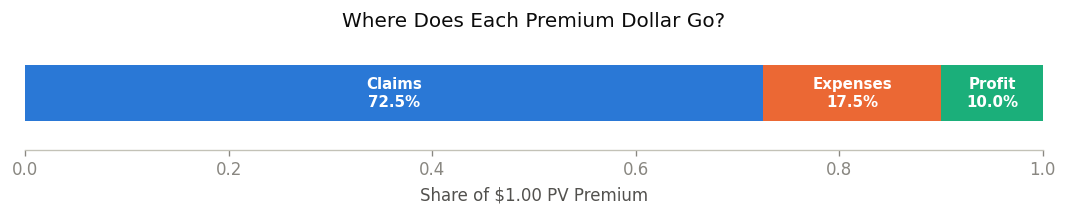

In [17]:
fig, ax = plt.subplots(figsize=(9, 1.9))

palette = {"Claims": BLUE, "Expenses": ORANGE, "Profit": AQUA}
left = 0.0
for _, row in components.iterrows():
    width = row["% of PV Premium"]
    ax.barh(0, width, left=left, color=palette[row["Component"]], height=0.6, zorder=2)
    if width > 0.05:
        ax.text(
            left + width / 2, 0, f"{row['Component']}\n{width:.1%}",
            ha="center", va="center", color="white", fontsize=9, fontweight="bold", zorder=3,
        )
    left += width

ax.set_xlim(0, 1)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel("Share of $1.00 PV Premium")
ax.set_title("Where Does Each Premium Dollar Go?")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

<a id="Part-6"></a>
## Part 6 — What actually drives the premium?

One-at-a-time assumption shocks, each priced through the exact same production pipeline
(`life_pricing.scenario.apply_scenario` + `price_policy_under_assumptions`) used for this
project's own Loop 9 sensitivity grids — nothing new is invented here.

$$ Elasticity = \frac{\%\Delta Premium}{\%\Delta Assumption} $$

In [18]:
def scenario_premium(mutate):
    scenario_assumptions = apply_scenario(ASSUMPTIONS, mutate)
    result = price_policy_under_assumptions(
        scenario_assumptions,
        issue_age=POLICY["issue_age"],
        sex=POLICY["sex"],
        smoker_status=POLICY["smoker_status"],
        underwriting_class=POLICY["underwriting_class"],
        face_amount=POLICY["face_amount"],
    )
    return result["annual_premium"]


baseline_premium = scenario_premium(lambda raw: None)
assert abs(baseline_premium - engine_premium) < 1e-6

perturbations = {}

perturbations["Mortality +10%"] = (
    scenario_premium(lambda raw: raw["mortality"].update(stress_multiplier=raw["mortality"]["stress_multiplier"] * 1.10)),
    0.10,
)
perturbations["Lapse +10%"] = (
    scenario_premium(lambda raw: raw["lapse"].update(
        by_duration={d: min(max(rate * 1.10, 0.0), 1.0) for d, rate in raw["lapse"]["by_duration"].items()}
    )),
    0.10,
)
perturbations["Expenses +10%"] = (
    scenario_premium(lambda raw: raw["expenses"].update({k: v * 1.10 for k, v in raw["expenses"].items()})),
    0.10,
)
perturbations["Interest 4%→5%"] = (
    scenario_premium(lambda raw: raw["interest"].update(annual_effective_rate=0.05)),
    (0.05 - 0.04) / 0.04,
)

rows = []
for name, (new_premium, pct_change_assumption) in perturbations.items():
    pct_change_premium = (new_premium - baseline_premium) / baseline_premium
    elasticity = pct_change_premium / pct_change_assumption
    rows.append({
        "Assumption shock": name,
        "Baseline premium": baseline_premium,
        "New premium": new_premium,
        "%Δ Premium": pct_change_premium,
        "%Δ Assumption": pct_change_assumption,
        "Elasticity": elasticity,
    })

elasticity_table = pd.DataFrame(rows).set_index("Assumption shock")
elasticity_display = elasticity_table.copy()
elasticity_display["Baseline premium"] = elasticity_display["Baseline premium"].map(lambda x: f"${x:,.2f}")
elasticity_display["New premium"] = elasticity_display["New premium"].map(lambda x: f"${x:,.2f}")
elasticity_display["%Δ Premium"] = elasticity_display["%Δ Premium"].map(lambda x: f"{x:.3%}")
elasticity_display["%Δ Assumption"] = elasticity_display["%Δ Assumption"].map(lambda x: f"{x:.2%}")
elasticity_display["Elasticity"] = elasticity_display["Elasticity"].map(lambda x: f"{x:.3f}")
elasticity_display

,Baseline premium,New premium,%Δ Premium,%Δ Assumption,Elasticity
Assumption shock,,,,,
Mortality +10%,$697.43,$758.01,8.685%,10.00%,0.869
Lapse +10%,$697.43,$689.41,-1.150%,10.00%,-0.115
Expenses +10%,$697.43,$712.25,2.125%,10.00%,0.212
Interest 4%→5%,$697.43,$669.50,-4.005%,25.00%,-0.160


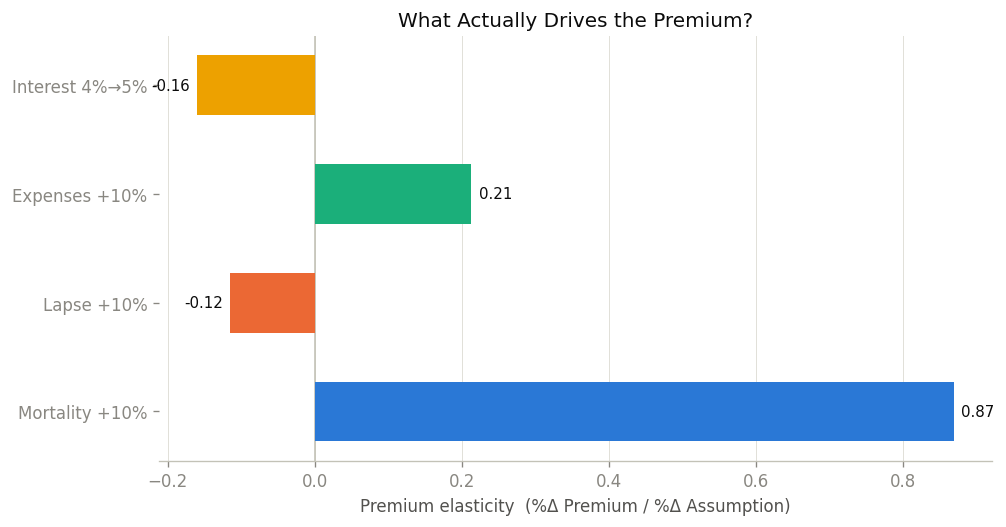

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

shock_colors = [BLUE, ORANGE, AQUA, YELLOW]
values = elasticity_table["Elasticity"]
bars = ax.barh(elasticity_table.index, values, color=shock_colors, height=0.55, zorder=2)

ax.axvline(0, color=BASELINE, linewidth=1.0, zorder=1)
ax.set_xlabel("Premium elasticity  (%Δ Premium / %Δ Assumption)")
ax.set_title("What Actually Drives the Premium?")
ax.grid(axis="x", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

for bar, value in zip(bars, values):
    offset = 0.01 * (1 if value >= 0 else -1)
    ha = "left" if value >= 0 else "right"
    ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
dominant = elasticity_table["Elasticity"].abs().idxmax()
print(f"Largest driver of the indicated premium for this policy: {dominant}")
print(f"  elasticity = {elasticity_table.loc[dominant, 'Elasticity']:.3f}")
print()
print("Full ranking (by |elasticity|, descending):")
ranked = elasticity_table.reindex(elasticity_table["Elasticity"].abs().sort_values(ascending=False).index)
for name, row in ranked.iterrows():
    print(f"  {name:<20s} elasticity = {row['Elasticity']:+.3f}")

Largest driver of the indicated premium for this policy: Mortality +10%
  elasticity = 0.869

Full ranking (by |elasticity|, descending):
  Mortality +10%       elasticity = +0.869
  Expenses +10%        elasticity = +0.212
  Interest 4%→5%       elasticity = -0.160
  Lapse +10%           elasticity = -0.115


An elasticity near $+1$ means the premium moves roughly in lockstep with the assumption; well
above $1$ means the premium is *more* sensitive than the assumption itself (leverage); well below
$1$ means the premium barely reacts. The ranking above — computed, not assumed — is the real
answer to "what actually drives the premium" for this specific 40-year-old $500,000 Standard
nonsmoker male policy under a 4% interest / 10% target-margin basis.